In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [3]:
import torch

checkpoint = torch.load("/kaggle/input/datasets/navyyaa/best-static-model/best_static_model.pth", map_location='cpu')

print("Keys in checkpoint:")
for key, value in checkpoint.items():
    print(f"  '{key}' → {type(value)}")

Keys in checkpoint:
  'epoch' → <class 'int'>
  'model_state_dict' → <class 'collections.OrderedDict'>
  'optimizer_state_dict' → <class 'dict'>
  'scheduler_state_dict' → <class 'dict'>
  'val_acc' → <class 'float'>


In [4]:
import numpy as np
import pandas as pd
import os
import pyarrow.parquet as pq
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

BASE_PATH = "/kaggle/input/competitions/asl-signs"
CSV_PATH  = "/kaggle/input/datasets/navyyaa/train-static-csv/train_static.csv"

df = pd.read_csv(CSV_PATH)
print(f"Total samples : {len(df)}")
print(f"Unique signs  : {df['sign'].nunique()}")

# ---- Rebuild label_map in same order as original training ----
label_map         = {label: idx for idx, label in enumerate(df["sign"].unique())}
reverse_label_map = {v: k for k, v in label_map.items()}
print(f"\nLabel map built: {len(label_map)} classes")

# ---- Re-extract features (same function as your original training) ----
def process_sequence(rel_path):
    full_path = os.path.join(BASE_PATH, rel_path)
    data = pq.read_table(full_path).to_pandas()

    data = data[data["type"].isin(["left_hand", "right_hand"])]
    if len(data) == 0:
        return None

    data   = data.sort_values(["frame", "landmark_index"])
    frames = data["frame"].unique()

    frame_features = []
    for f in frames:
        frame_data = data[data["frame"] == f]
        coords     = frame_data[["x", "y", "z"]].values
        coords     = np.nan_to_num(coords)

        if len(coords) >= 42:
            left_wrist  = coords[0]
            right_wrist = coords[21]
            coords[:21]  -= left_wrist
            coords[21:42] -= right_wrist

        frame_features.append(coords.flatten())

    frame_features   = np.array(frame_features)
    sequence_feature = frame_features.mean(axis=0)
    return sequence_feature

print("\nExtracting baseline features (same as original training)...")
X, y = [], []

for _, row in tqdm(df.iterrows(), total=len(df)):
    feat = process_sequence(row["path"])
    if feat is not None:
        X.append(feat)
        y.append(label_map[row["sign"]])

X = np.array(X)
y = np.array(y)
print(f"\n✓ Features shape : {X.shape}")

# ---- Split (same seed as original) ----
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# ---- Rebuild scaler ----
scaler      = StandardScaler()
X_train_sc  = scaler.fit_transform(X_train)
X_val_sc    = scaler.transform(X_val)

print(f"\n✓ Train : {X_train.shape}")
print(f"✓ Val   : {X_val.shape}")
print(f"✓ Scaler fitted")
print("\n✅ BLOCK 0 COMPLETE — continue to Block 1")


Total samples : 47446
Unique signs  : 125

Label map built: 125 classes

Extracting baseline features (same as original training)...


100%|██████████| 47446/47446 [41:10<00:00, 19.21it/s]  



✓ Features shape : (47446, 126)

✓ Train : (37956, 126)
✓ Val   : (9490, 126)
✓ Scaler fitted

✅ BLOCK 0 COMPLETE — continue to Block 1


✓ Model loaded successfully!
✓ Saved epoch   : 43
✓ Saved val_acc : 0.5805

  Baseline Accuracy  : 0.5807  (58.07%)
  Correct            : 5511 / 9490
  Mean conf (all)    : 0.5101
  Mean conf (correct): 0.6455
  Mean conf (wrong)  : 0.3225

  TOP 20 CONFUSED SIGN PAIRS
-----------------------------------------------------------------
   1. awake              → wake               (34x)
   2. chin               → say                (32x)
   3. please             → minemy             (26x)
   4. finger             → wait               (25x)
   5. mouse              → shhh               (20x)
   6. yesterday          → cow                (19x)
   7. animal             → have               (19x)
   8. animal             → bath               (17x)
   9. jacket             → bath               (16x)
  10. mouth              → say                (16x)
  11. wake               → awake              (14x)
  12. minemy             → please             (14x)
  13. not                → nuts        

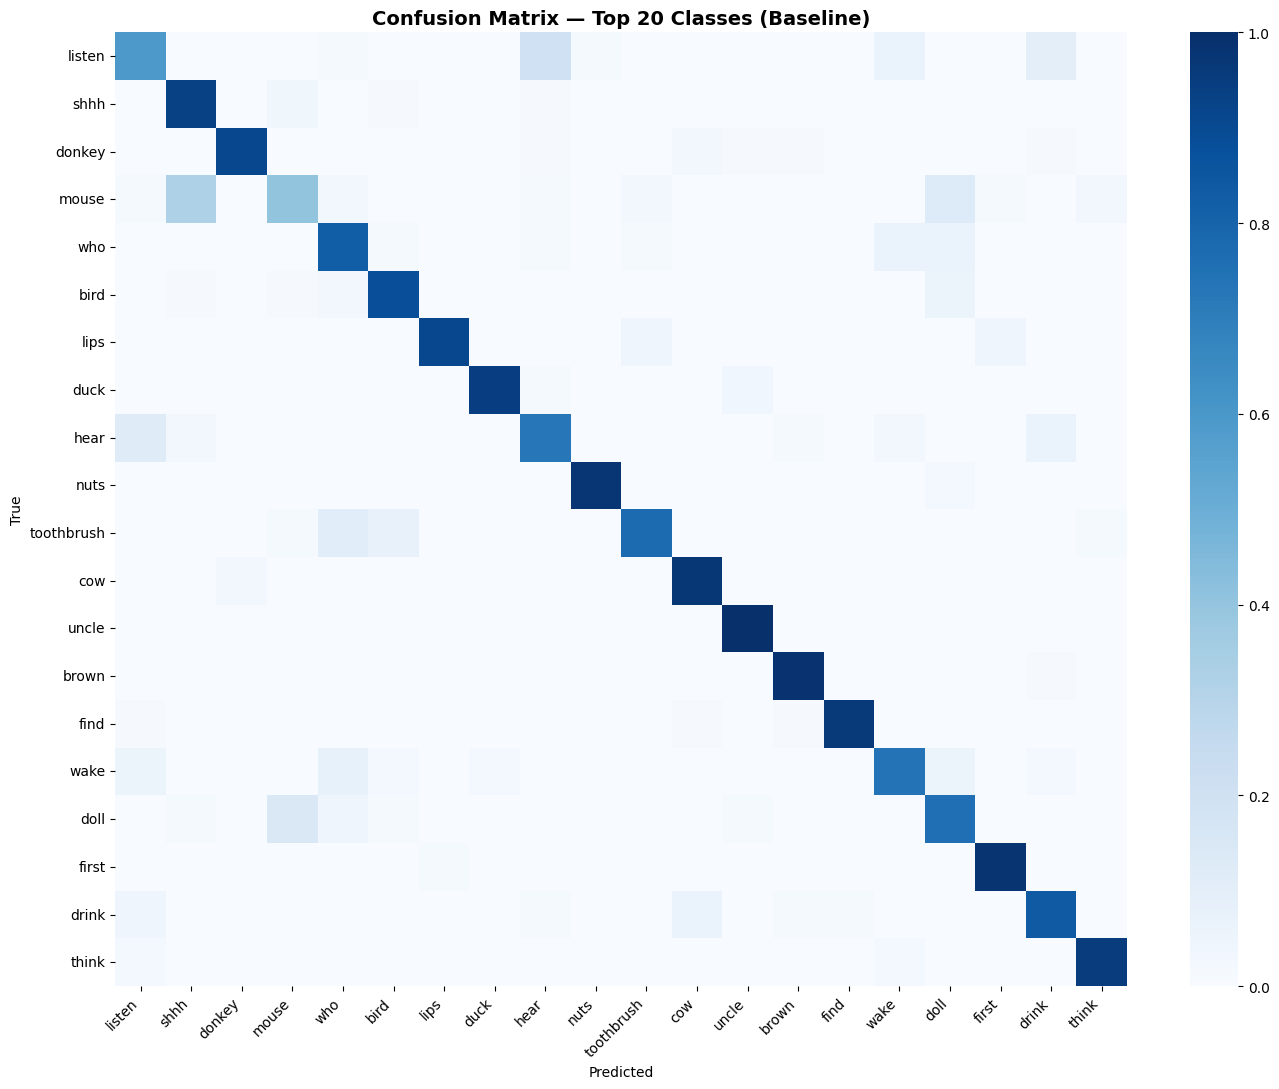


✅ BLOCK 1 COMPLETE — continue to Block 2


In [6]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

MODEL_PATH = "/kaggle/input/datasets/navyyaa/best-static-model/best_static_model.pth"

checkpoint  = torch.load(MODEL_PATH, map_location='cpu')
input_dim   = X_train.shape[1]   # 126
num_classes = len(label_map)     # 125

# ---- CORRECT architecture reverse-engineered from the error message ----
# Error showed: net.8=Linear(256→128), net.9=BN(128), net.12=Linear(128→out)
# So the real saved model has 3 hidden layers: 512 → 256 → 128 → 125

class MLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),   # net.0
            nn.BatchNorm1d(512),          # net.1
            nn.ReLU(),                    # net.2
            nn.Dropout(0.3),              # net.3

            nn.Linear(512, 256),          # net.4
            nn.BatchNorm1d(256),          # net.5
            nn.ReLU(),                    # net.6
            nn.Dropout(0.3),              # net.7

            nn.Linear(256, 128),          # net.8  ← this was missing before
            nn.BatchNorm1d(128),          # net.9
            nn.ReLU(),                    # net.10
            nn.Dropout(0.3),              # net.11

            nn.Linear(128, num_classes)   # net.12
        )
    def forward(self, x):
        return self.net(x)

# ---- Load weights ----
model = MLP(input_dim, num_classes)
model.load_state_dict(checkpoint['model_state_dict'])

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = model.to(device)
model.eval()

print(f"✓ Model loaded successfully!")
print(f"✓ Saved epoch   : {checkpoint['epoch']}")
print(f"✓ Saved val_acc : {checkpoint['val_acc']:.4f}")

# ---- Predictions ----
val_tensor = torch.tensor(X_val_sc, dtype=torch.float32).to(device)

with torch.no_grad():
    logits        = model(val_tensor)
    y_pred        = logits.argmax(dim=1).cpu().numpy()
    probabilities = torch.softmax(logits, dim=1).cpu().numpy()

confidence   = probabilities.max(axis=1)
baseline_acc = (y_val == y_pred).mean()

print("\n" + "="*65)
print(f"  Baseline Accuracy  : {baseline_acc:.4f}  ({baseline_acc*100:.2f}%)")
print(f"  Correct            : {(y_val == y_pred).sum()} / {len(y_val)}")
print("="*65)
print(f"  Mean conf (all)    : {confidence.mean():.4f}")
print(f"  Mean conf (correct): {confidence[y_val == y_pred].mean():.4f}")
print(f"  Mean conf (wrong)  : {confidence[y_val != y_pred].mean():.4f}")

# ---- Top 20 confused pairs ----
print("\n  TOP 20 CONFUSED SIGN PAIRS")
print("-"*65)

conf_counts = {}
for t, p in zip(y_val, y_pred):
    if t != p:
        conf_counts[(t, p)] = conf_counts.get((t, p), 0) + 1

for i, ((t, p), c) in enumerate(
        sorted(conf_counts.items(), key=lambda x: x[1], reverse=True)[:20], 1):
    print(f"  {i:2d}. {reverse_label_map[t]:18s} → {reverse_label_map[p]:18s} ({c}x)")

# ---- Confusion matrix ----
unique, counts = np.unique(y_val, return_counts=True)
top20          = unique[np.argsort(-counts)[:20]]
mask           = np.isin(y_val, top20)

cm      = confusion_matrix(y_val[mask], y_pred[mask], labels=top20)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(cm_norm, annot=False, cmap='Blues',
            xticklabels=[reverse_label_map[i] for i in top20],
            yticklabels=[reverse_label_map[i] for i in top20], ax=ax)
ax.set_title('Confusion Matrix — Top 20 Classes (Baseline)', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('confusion_baseline.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ BLOCK 1 COMPLETE — continue to Block 2")

In [7]:
# ============================================================================
# BLOCK 2: DEFINE IMPROVED MODEL ARCHITECTURE
# ============================================================================

import torch
import torch.nn as nn
import torch.optim as optim

class ResidualBlock(nn.Module):
    """Residual block with skip connection"""
    def __init__(self, in_dim, out_dim, dropout=0.3):
        super().__init__()
        
        self.fc1 = nn.Linear(in_dim, out_dim)
        self.bn1 = nn.BatchNorm1d(out_dim)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        
        self.fc2 = nn.Linear(out_dim, out_dim)
        self.bn2 = nn.BatchNorm1d(out_dim)
        
        # Skip connection
        if in_dim != out_dim:
            self.skip = nn.Linear(in_dim, out_dim)
        else:
            self.skip = nn.Identity()
    
    def forward(self, x):
        identity = self.skip(x)
        
        out = self.fc1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)
        
        out = self.fc2(out)
        out = self.bn2(out)
        
        out += identity
        out = self.relu(out)
        
        return out


class ImprovedMLP(nn.Module):
    """Improved MLP with residual connections"""
    def __init__(self, input_dim, num_classes, hidden_dims=[1024, 512, 512, 256]):
        super().__init__()
        
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, hidden_dims[0]),
            nn.BatchNorm1d(hidden_dims[0]),
            nn.ReLU(),
            nn.Dropout(0.4)
        )
        
        # Residual blocks
        self.res_block1 = ResidualBlock(hidden_dims[0], hidden_dims[1])
        self.res_block2 = ResidualBlock(hidden_dims[1], hidden_dims[2])
        self.res_block3 = ResidualBlock(hidden_dims[2], hidden_dims[3])
        
        self.output_layer = nn.Linear(hidden_dims[3], num_classes)
        
        # Initialize weights
        self.apply(self._init_weights)
    
    def _init_weights(self, m):
        if isinstance(m, nn.Linear):
            nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            if m.bias is not None:
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        x = self.res_block3(x)
        x = self.output_layer(x)
        return x

print("✓ Improved architecture defined!")

✓ Improved architecture defined!


In [8]:
# ============================================================================
# BLOCK 3: TRAIN IMPROVED MODEL (SAME FEATURES, BETTER ARCHITECTURE)
# ============================================================================

from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

class SignDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Use your existing X_train, X_val, y_train, y_val
# Re-scale with new scaler
scaler_v2 = StandardScaler()
X_train_scaled_v2 = scaler_v2.fit_transform(X_train)
X_val_scaled_v2 = scaler_v2.transform(X_val)

# Create datasets
train_dataset = SignDataset(X_train_scaled_v2, y_train)
val_dataset = SignDataset(X_val_scaled_v2, y_val)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)

# Initialize improved model
input_dim = X_train.shape[1]
num_classes = len(np.unique(y_train))

model_v2 = ImprovedMLP(input_dim, num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_v2 = model_v2.to(device)

# Loss with label smoothing
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# Optimizer with weight decay
optimizer = optim.AdamW(model_v2.parameters(), lr=1e-3, weight_decay=1e-4)

# Cosine annealing scheduler
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

# Training loop
EPOCHS = 100
best_val_acc = 0
patience = 15
patience_counter = 0

print("\n" + "=" * 80)
print("TRAINING IMPROVED MODEL (SAME FEATURES)")
print("=" * 80)
print(f"Device: {device}")
print(f"Epochs: {EPOCHS}, Patience: {patience}")
print("-" * 80)

for epoch in range(EPOCHS):
    # TRAIN
    model_v2.train()
    train_loss = 0
    correct = 0
    
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        
        optimizer.zero_grad()
        outputs = model_v2(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        
        # Gradient clipping
        torch.nn.utils.clip_grad_norm_(model_v2.parameters(), max_norm=1.0)
        
        optimizer.step()
        
        train_loss += loss.item() * X_batch.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == y_batch).sum().item()
    
    train_loss = train_loss / len(train_dataset)
    train_acc = correct / len(train_dataset)
    
    # VALIDATE
    model_v2.eval()
    val_loss = 0
    correct = 0
    
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            outputs = model_v2(X_batch)
            loss = criterion(outputs, y_batch)
            
            val_loss += loss.item() * X_batch.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == y_batch).sum().item()
    
    val_loss = val_loss / len(val_dataset)
    val_acc = correct / len(val_dataset)
    
    # Update scheduler
    scheduler.step()
    
    # Print progress every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_counter = 0
        
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_v2.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler': scaler_v2,
            'label_map': label_map,
            'val_accuracy': val_acc
        }, "best_improved_mlp_same_features.pth")
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"  ✅ New best! Val Acc: {val_acc:.4f}")
    else:
        patience_counter += 1
    
    # Early stopping
    if patience_counter >= patience:
        print(f"\n⏹️ Early stopping at epoch {epoch+1}")
        break

print("\n" + "=" * 80)
print(f"✅ TRAINING COMPLETE!")
print(f"Best Validation Accuracy: {best_val_acc:.4f}")
print(f"Improvement over baseline: +{(best_val_acc - accuracy)*100:.2f}%")
print("=" * 80)


TRAINING IMPROVED MODEL (SAME FEATURES)
Device: cuda
Epochs: 100, Patience: 15
--------------------------------------------------------------------------------
Epoch   1/100 | Train Loss: 4.6006 Acc: 0.0753 | Val Loss: 3.7646 Acc: 0.1884
  ✅ New best! Val Acc: 0.1884
Epoch   5/100 | Train Loss: 2.8411 Acc: 0.3852 | Val Loss: 2.6758 Acc: 0.4405
  ✅ New best! Val Acc: 0.4405
Epoch  10/100 | Train Loss: 2.4881 Acc: 0.4891 | Val Loss: 2.4448 Acc: 0.5086
  ✅ New best! Val Acc: 0.5086
Epoch  15/100 | Train Loss: 2.4243 Acc: 0.5003 | Val Loss: 2.3610 Acc: 0.5283
  ✅ New best! Val Acc: 0.5283
Epoch  20/100 | Train Loss: 2.1973 Acc: 0.5703 | Val Loss: 2.2306 Acc: 0.5624
  ✅ New best! Val Acc: 0.5624
Epoch  25/100 | Train Loss: 2.0272 Acc: 0.6219 | Val Loss: 2.1503 Acc: 0.5999
  ✅ New best! Val Acc: 0.5999
Epoch  30/100 | Train Loss: 1.9564 Acc: 0.6464 | Val Loss: 2.1248 Acc: 0.6095
Epoch  35/100 | Train Loss: 2.1107 Acc: 0.5916 | Val Loss: 2.2079 Acc: 0.5793
Epoch  40/100 | Train Loss: 1.9931 

NameError: name 'accuracy' is not defined

In [10]:
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

class SignDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

# ---- Loaders ----
train_loader = DataLoader(SignDataset(X_train_sc, y_train), batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(SignDataset(X_val_sc,   y_val),   batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# ---- Model ----
model_v2  = ImprovedMLP(input_dim, num_classes).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# AdamW with lower LR + ReduceLROnPlateau (no spikes)
optimizer = optim.AdamW(model_v2.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6
)

EPOCHS           = 100
best_acc_v2      = 0.0
patience         = 20          # more patience now that LR decays properly
patience_counter = 0
history          = {'train_acc': [], 'val_acc': [], 'lr': []}

print("="*65)
print("  TRAINING: Improved Architecture + Same Features (FIXED)")
print(f"  Device: {device}  |  LR: 3e-4 → ReduceLROnPlateau")
print(f"  Epochs: {EPOCHS}  |  Patience: {patience}")
print("="*65)

for epoch in range(EPOCHS):

    # -- Train --
    model_v2.train()
    correct, total = 0, 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model_v2(Xb)
        loss = criterion(out, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_v2.parameters(), 1.0)
        optimizer.step()
        correct += (out.argmax(1) == yb).sum().item()
        total   += yb.size(0)
    train_acc = correct / total

    # -- Validate --
    model_v2.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader:
            Xb, yb = Xb.to(device), yb.to(device)
            out     = model_v2(Xb)
            correct += (out.argmax(1) == yb).sum().item()
            total   += yb.size(0)
    val_acc = correct / total

    # ReduceLROnPlateau steps on val accuracy (no spikes)
    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | LR: {current_lr:.2e}", end="")

    if val_acc > best_acc_v2:
        best_acc_v2      = val_acc
        patience_counter = 0
        torch.save({
            'epoch': epoch,
            'model_state_dict': model_v2.state_dict(),
            'val_acc': val_acc
        }, "best_improved_same_features.pth")
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print("  ✅ saved", end="")
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print()

    if patience_counter >= patience:
        print(f"\n  ⏹️ Early stopping at epoch {epoch+1}")
        break

print(f"\n  Baseline accuracy          : {baseline_acc:.4f}  ({baseline_acc*100:.2f}%)")
print(f"  Improved (same features)   : {best_acc_v2:.4f}  ({best_acc_v2*100:.2f}%)")
print(f"  Gain                       : +{(best_acc_v2 - baseline_acc)*100:.2f}%")
print("\n✅ BLOCK 3 COMPLETE — continue to Block 4")

  TRAINING: Improved Architecture + Same Features (FIXED)
  Device: cuda  |  LR: 3e-4 → ReduceLROnPlateau
  Epochs: 100  |  Patience: 20
  Epoch   1 | Train: 0.0395 | Val: 0.1224 | LR: 3.00e-04  ✅ saved
  Epoch   5 | Train: 0.2991 | Val: 0.3791 | LR: 3.00e-04  ✅ saved
  Epoch  10 | Train: 0.4253 | Val: 0.4776 | LR: 3.00e-04  ✅ saved
  Epoch  15 | Train: 0.4926 | Val: 0.5276 | LR: 3.00e-04  ✅ saved
  Epoch  20 | Train: 0.5353 | Val: 0.5569 | LR: 3.00e-04  ✅ saved
  Epoch  25 | Train: 0.5666 | Val: 0.5778 | LR: 3.00e-04
  Epoch  30 | Train: 0.5955 | Val: 0.5941 | LR: 3.00e-04  ✅ saved
  Epoch  35 | Train: 0.6188 | Val: 0.6011 | LR: 3.00e-04
  Epoch  40 | Train: 0.6379 | Val: 0.6161 | LR: 3.00e-04  ✅ saved
  Epoch  45 | Train: 0.6575 | Val: 0.6177 | LR: 3.00e-04
  Epoch  50 | Train: 0.6758 | Val: 0.6271 | LR: 3.00e-04  ✅ saved
  Epoch  55 | Train: 0.6898 | Val: 0.6279 | LR: 3.00e-04
  Epoch  60 | Train: 0.7215 | Val: 0.6406 | LR: 1.50e-04  ✅ saved
  Epoch  65 | Train: 0.7398 | Val: 0.6436

In [11]:
# ============================================================================
# BLOCK 4: EXTRACT STATIC-OPTIMIZED FEATURES
# ============================================================================

import os
import pyarrow.parquet as pq
from scipy.spatial.distance import euclidean
from tqdm import tqdm

BASE_PATH = "/kaggle/input/competitions/asl-signs"

def extract_static_hand_features(rel_path):
    """Extract hand shape features for static signs"""
    
    full_path = os.path.join(BASE_PATH, rel_path)
    data = pq.read_table(full_path).to_pandas()
    
    # Filter to hands
    data = data[data["type"].isin(["left_hand", "right_hand"])]
    
    if len(data) == 0:
        return None
    
    data = data.sort_values(["frame", "landmark_index"])
    frames = sorted(data["frame"].unique())
    
    # Use middle frames (more stable for static signs)
    if len(frames) > 5:
        start_idx = len(frames) // 4
        end_idx = 3 * len(frames) // 4
        frames = frames[start_idx:end_idx]
    
    all_features = []
    
    for f in frames:
        frame_data = data[data["frame"] == f]
        coords = frame_data[["x", "y", "z"]].values
        coords = np.nan_to_num(coords)
        
        if len(coords) < 42:
            continue
        
        # Normalize to wrists
        left_wrist = coords[0]
        right_wrist = coords[21]
        
        left_hand = coords[:21] - left_wrist
        right_hand = coords[21:42] - right_wrist
        
        # Extract features for this frame
        features = []
        
        # 1. FINGER EXTENSIONS (10 features)
        for hand in [left_hand, right_hand]:
            wrist = hand[0]
            # Thumb
            thumb_ext = euclidean(wrist, hand[4]) / (euclidean(hand[1], hand[4]) + 1e-6)
            features.append(thumb_ext)
            # Other fingers
            for base in [5, 9, 13, 17]:
                tip = base + 3
                ext = euclidean(wrist, hand[tip]) / (euclidean(hand[base], hand[tip]) + 1e-6)
                features.append(ext)
        
        # 2. FINGERTIP DISTANCES (20 features)
        for hand in [left_hand, right_hand]:
            tips = hand[[4, 8, 12, 16, 20]]
            for i in range(5):
                for j in range(i+1, 5):
                    dist = euclidean(tips[i], tips[j])
                    features.append(dist)
        
        # 3. PALM ORIENTATION (7 features)
        def palm_normal(hand):
            v1 = hand[5] - hand[0]  # wrist to index base
            v2 = hand[17] - hand[0]  # wrist to pinky base
            normal = np.cross(v1, v2)
            return normal / (np.linalg.norm(normal) + 1e-6)
        
        left_normal = palm_normal(left_hand)
        right_normal = palm_normal(right_hand)
        features.extend(left_normal)
        features.extend(right_normal)
        palm_angle = np.arccos(np.clip(np.dot(left_normal, right_normal), -1, 1))
        features.append(palm_angle)
        
        # 4. HAND OPENNESS (4 features)
        for hand in [left_hand, right_hand]:
            wrist = hand[0]
            tips = hand[[4, 8, 12, 16, 20]]
            avg_dist = np.mean([euclidean(wrist, tip) for tip in tips])
            spread = np.std(tips, axis=0).mean()
            features.extend([avg_dist, spread])
        
        # 5. THUMB-FINGER DISTANCES (8 features)
        for hand in [left_hand, right_hand]:
            thumb_tip = hand[4]
            other_tips = hand[[8, 12, 16, 20]]
            for tip in other_tips:
                features.append(euclidean(thumb_tip, tip))
        
        # 6. TWO-HAND FEATURES (4 features)
        left_center = left_hand.mean(axis=0)
        right_center = right_hand.mean(axis=0)
        hand_dist = euclidean(left_center, right_center)
        features.append(hand_dist)
        features.extend(right_center - left_center)  # 3D relative position
        
        all_features.append(features)
    
    if not all_features:
        return None
    
    # Use MEDIAN for static signs (more robust)
    features_median = np.median(all_features, axis=0)
    
    # Add variation (should be low for static)
    variation = np.std(all_features, axis=0)
    
    return np.concatenate([features_median, variation])


# Extract features for all samples
print("\n" + "=" * 80)
print("EXTRACTING STATIC-OPTIMIZED FEATURES")
print("=" * 80)
print("This will take 20-30 minutes...")
print("-" * 80)

df = pd.read_csv("/kaggle/input/datasets/navyyaa/train-static-csv/train_static.csv")

X_static = []
y_static = []

for _, row in tqdm(df.iterrows(), total=len(df), desc="Processing"):
    feat = extract_static_hand_features(row["path"])
    
    if feat is not None:
        X_static.append(feat)
        y_static.append(label_map[row["sign"]])

X_static = np.array(X_static)
y_static = np.array(y_static)

print(f"\n✓ Feature extraction complete!")
print(f"  Shape: {X_static.shape}")
print(f"  Samples: {len(y_static)}")
print(f"  Features per sample: {X_static.shape[1]}")


EXTRACTING STATIC-OPTIMIZED FEATURES
This will take 20-30 minutes...
--------------------------------------------------------------------------------


Processing: 100%|██████████| 47446/47446 [41:04<00:00, 19.25it/s]  


✓ Feature extraction complete!
  Shape: (47446, 106)
  Samples: 47446
  Features per sample: 106


In [14]:
import numpy as np
import os
import pyarrow.parquet as pq
from scipy.spatial.distance import euclidean
from tqdm import tqdm

BASE_PATH = "/kaggle/input/competitions/asl-signs"

def extract_static_features(rel_path):
    full_path = os.path.join(BASE_PATH, rel_path)
    data = pq.read_table(full_path).to_pandas()

    data = data[data["type"].isin(["left_hand", "right_hand"])]
    if len(data) == 0:
        return None

    data   = data.sort_values(["frame", "landmark_index"])
    frames = sorted(data["frame"].unique())

    if len(frames) > 5:
        s = len(frames) // 4
        e = 3 * len(frames) // 4
        frames = frames[s:e]

    all_frame_feats = []

    for f in frames:
        coords = data[data["frame"] == f][["x", "y", "z"]].values
        coords = np.nan_to_num(coords)

        if len(coords) < 42:
            continue

        lh = coords[:21]   - coords[0]
        rh = coords[21:42] - coords[21]

        feats = []

        # 1. FINGER EXTENSIONS (10)
        for hand in [lh, rh]:
            feats.append(euclidean(hand[0], hand[4]) / (euclidean(hand[1],  hand[4])  + 1e-6))
            for base in [5, 9, 13, 17]:
                feats.append(euclidean(hand[0], hand[base+3]) / (euclidean(hand[base], hand[base+3]) + 1e-6))

        # 2. FINGERTIP PAIRWISE DISTANCES (20)
        for hand in [lh, rh]:
            tips = hand[[4, 8, 12, 16, 20]]
            for i in range(5):
                for j in range(i+1, 5):
                    feats.append(euclidean(tips[i], tips[j]))

        # 3. PALM ORIENTATION (7)
        def palm_normal(hand):
            n = np.cross(hand[5] - hand[0], hand[17] - hand[0])
            return n / (np.linalg.norm(n) + 1e-6)

        ln = palm_normal(lh)
        rn = palm_normal(rh)
        feats.extend(ln)
        feats.extend(rn)
        feats.append(np.arccos(np.clip(np.dot(ln, rn), -1, 1)))

        # 4. HAND OPENNESS (4)
        for hand in [lh, rh]:
            tips = hand[[4, 8, 12, 16, 20]]
            feats.append(np.mean([euclidean(hand[0], t) for t in tips]))
            feats.append(np.std(tips, axis=0).mean())

        # 5. THUMB-TO-FINGER DISTANCES (8)
        for hand in [lh, rh]:
            for tip_idx in [8, 12, 16, 20]:
                feats.append(euclidean(hand[4], hand[tip_idx]))

        # 6. TWO-HAND RELATIONSHIP (4)
        lc = lh.mean(axis=0)
        rc = rh.mean(axis=0)
        feats.append(euclidean(lc, rc))
        feats.extend(rc - lc)

        all_frame_feats.append(feats)

    if not all_frame_feats:
        return None

    arr = np.array(all_frame_feats)
    return np.concatenate([np.median(arr, axis=0), arr.std(axis=0)])


# ---- Extract ----
print("Extracting static features (~40 min)...\n")

X_st, y_st = [], []

for _, row in tqdm(df.iterrows(), total=len(df)):
    feat = extract_static_features(row["path"])
    if feat is not None:
        X_st.append(feat)
        y_st.append(label_map[row["sign"]])

X_st = np.array(X_st)
y_st = np.array(y_st)

print(f"\n✓ Shape  : {X_st.shape}")
print(f"✓ Samples: {len(y_st)}")

# ---- SAVE IMMEDIATELY ----
np.save("/kaggle/working/X_static_features.npy", X_st)
np.save("/kaggle/working/y_static_features.npy", y_st)

print("\n✓ Saved to /kaggle/working/X_static_features.npy")
print("✓ Saved to /kaggle/working/y_static_features.npy")
print("\n✅ BLOCK 4 COMPLETE — continue to Block 5")

Extracting static features (~40 min)...



100%|██████████| 47446/47446 [43:11<00:00, 18.31it/s]  



✓ Shape  : (47446, 106)
✓ Samples: 47446

✓ Saved to /kaggle/working/X_static_features.npy
✓ Saved to /kaggle/working/y_static_features.npy

✅ BLOCK 4 COMPLETE — continue to Block 5


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ---- Split static features (same seed as always) ----
X_tr_st, X_va_st, y_tr_st, y_va_st = train_test_split(
    X_st, y_st, test_size=0.2, stratify=y_st, random_state=42
)

# ---- Scale ----
scaler_st  = StandardScaler()
X_tr_st_sc = scaler_st.fit_transform(X_tr_st)
X_va_st_sc = scaler_st.transform(X_va_st)

print(f"✓ Train : {X_tr_st_sc.shape}")
print(f"✓ Val   : {X_va_st_sc.shape}")

# ---- Loaders ----
train_loader_st = DataLoader(SignDataset(X_tr_st_sc, y_tr_st), batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_st   = DataLoader(SignDataset(X_va_st_sc, y_va_st), batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# ---- Model with new input dim (106) ----
input_dim_st = X_tr_st_sc.shape[1]   # 106
print(f"✓ Input dim : {input_dim_st}")

model_st  = ImprovedMLP(input_dim_st, num_classes).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model_st.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6
)

EPOCHS           = 100
best_acc_st      = 0.0
patience         = 20
patience_counter = 0
history_st       = {'train_acc': [], 'val_acc': [], 'lr': []}

print("\n" + "="*65)
print("  TRAINING: Improved Architecture + Static Features")
print(f"  Device: {device}  |  Input dim: {input_dim_st}  |  Classes: {num_classes}")
print(f"  Epochs: {EPOCHS}  |  Patience: {patience}")
print("="*65)

for epoch in range(EPOCHS):

    # -- Train --
    model_st.train()
    correct, total = 0, 0
    for Xb, yb in train_loader_st:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model_st(Xb)
        loss = criterion(out, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_st.parameters(), 1.0)
        optimizer.step()
        correct += (out.argmax(1) == yb).sum().item()
        total   += yb.size(0)
    train_acc = correct / total

    # -- Validate --
    model_st.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader_st:
            Xb, yb = Xb.to(device), yb.to(device)
            out     = model_st(Xb)
            correct += (out.argmax(1) == yb).sum().item()
            total   += yb.size(0)
    val_acc = correct / total

    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']

    history_st['train_acc'].append(train_acc)
    history_st['val_acc'].append(val_acc)
    history_st['lr'].append(current_lr)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | LR: {current_lr:.2e}", end="")

    if val_acc > best_acc_st:
        best_acc_st      = val_acc
        patience_counter = 0
        torch.save({
            'epoch'            : epoch,
            'model_state_dict' : model_st.state_dict(),
            'val_acc'          : val_acc,
            'input_dim'        : input_dim_st,
            'num_classes'      : num_classes
        }, "best_static_features_model.pth")
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print("  ✅ saved", end="")
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print()

    if patience_counter >= patience:
        print(f"\n  ⏹️ Early stopping at epoch {epoch+1}")
        break

print("\n" + "="*65)
print("  FINAL RESULTS")
print("="*65)
print(f"  Baseline accuracy          : {baseline_acc:.4f}  ({baseline_acc*100:.2f}%)")
print(f"  Improved (same features)   : {best_acc_v2:.4f}  ({best_acc_v2*100:.2f}%)")
print(f"  Improved (static features) : {best_acc_st:.4f}  ({best_acc_st*100:.2f}%)")
print(f"  Total gain over baseline   : +{(best_acc_st - baseline_acc)*100:.2f}%")
print("="*65)
print("\n✅ BLOCK 5 COMPLETE — continue to Block 6")

✓ Train : (37956, 106)
✓ Val   : (9490, 106)
✓ Input dim : 106

  TRAINING: Improved Architecture + Static Features
  Device: cuda  |  Input dim: 106  |  Classes: 125
  Epochs: 100  |  Patience: 20
  Epoch   1 | Train: 0.0172 | Val: 0.0388 | LR: 3.00e-04  ✅ saved
  Epoch   5 | Train: 0.1768 | Val: 0.2335 | LR: 3.00e-04  ✅ saved
  Epoch  10 | Train: 0.3034 | Val: 0.3475 | LR: 3.00e-04  ✅ saved
  Epoch  15 | Train: 0.3700 | Val: 0.4008 | LR: 3.00e-04  ✅ saved
  Epoch  20 | Train: 0.4143 | Val: 0.4220 | LR: 3.00e-04  ✅ saved
  Epoch  25 | Train: 0.4484 | Val: 0.4429 | LR: 3.00e-04  ✅ saved
  Epoch  30 | Train: 0.4734 | Val: 0.4615 | LR: 3.00e-04  ✅ saved
  Epoch  35 | Train: 0.5038 | Val: 0.4659 | LR: 3.00e-04
  Epoch  40 | Train: 0.5265 | Val: 0.4762 | LR: 3.00e-04
  Epoch  45 | Train: 0.5458 | Val: 0.4891 | LR: 3.00e-04  ✅ saved
  Epoch  50 | Train: 0.5638 | Val: 0.4907 | LR: 3.00e-04
  Epoch  55 | Train: 0.5769 | Val: 0.4949 | LR: 3.00e-04
  Epoch  60 | Train: 0.6024 | Val: 0.4946 | LR

In [16]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch
import torch.nn as nn
import torch.optim as optim

# ---- Reload static features ----
X_st = np.load("/kaggle/working/X_static_features.npy")
y_st = np.load("/kaggle/working/y_static_features.npy")

print(f"✓ Original features shape  : {X.shape}")       # (47446, 126)
print(f"✓ Static features shape    : {X_st.shape}")     # (47446, 106)

# ---- COMBINE both feature sets ----
# Original = raw coordinates (absolute position info)
# Static   = finger angles, palm orientation, distances (shape info)
# Together = best of both worlds

X_combined = np.hstack([X, X_st])   # (47446, 232)
y_combined = y                       # labels same for both

print(f"✓ Combined features shape  : {X_combined.shape}")  # (47446, 232)

# ---- Split ----
X_tr_c, X_va_c, y_tr_c, y_va_c = train_test_split(
    X_combined, y_combined, test_size=0.2, stratify=y_combined, random_state=42
)

# ---- Scale ----
scaler_c  = StandardScaler()
X_tr_c_sc = scaler_c.fit_transform(X_tr_c)
X_va_c_sc = scaler_c.transform(X_va_c)

print(f"✓ Train : {X_tr_c_sc.shape}")
print(f"✓ Val   : {X_va_c_sc.shape}")

# ---- Loaders ----
class SignDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader_c = DataLoader(SignDataset(X_tr_c_sc, y_tr_c), batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_c   = DataLoader(SignDataset(X_va_c_sc, y_va_c), batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# ---- Model with combined input dim ----
input_dim_c = X_tr_c_sc.shape[1]   # 232
num_classes = len(np.unique(y_tr_c))

print(f"✓ Input dim  : {input_dim_c}")
print(f"✓ Classes    : {num_classes}")
print(f"✓ Device     : {device}")

model_c   = ImprovedMLP(input_dim_c, num_classes).to(device)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model_c.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5, min_lr=1e-6
)

EPOCHS           = 100
best_acc_c       = 0.0
patience         = 20
patience_counter = 0
history_c        = {'train_acc': [], 'val_acc': [], 'lr': []}

print("\n" + "="*65)
print("  TRAINING: Improved Arch + COMBINED Features (126 + 106)")
print(f"  Device: {device}  |  Input dim: {input_dim_c}  |  Classes: {num_classes}")
print(f"  Epochs: {EPOCHS}  |  Patience: {patience}")
print("="*65)

for epoch in range(EPOCHS):

    # -- Train --
    model_c.train()
    correct, total = 0, 0
    for Xb, yb in train_loader_c:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model_c(Xb)
        loss = criterion(out, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_c.parameters(), 1.0)
        optimizer.step()
        correct += (out.argmax(1) == yb).sum().item()
        total   += yb.size(0)
    train_acc = correct / total

    # -- Validate --
    model_c.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader_c:
            Xb, yb = Xb.to(device), yb.to(device)
            out     = model_c(Xb)
            correct += (out.argmax(1) == yb).sum().item()
            total   += yb.size(0)
    val_acc = correct / total

    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']

    history_c['train_acc'].append(train_acc)
    history_c['val_acc'].append(val_acc)
    history_c['lr'].append(current_lr)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | LR: {current_lr:.2e}", end="")

    if val_acc > best_acc_c:
        best_acc_c       = val_acc
        patience_counter = 0
        torch.save({
            'epoch'           : epoch,
            'model_state_dict': model_c.state_dict(),
            'val_acc'         : val_acc,
            'input_dim'       : input_dim_c,
            'num_classes'     : num_classes
        }, "/kaggle/working/best_combined_model.pth")
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print("  ✅ saved", end="")
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print()

    if patience_counter >= patience:
        print(f"\n  ⏹️ Early stopping at epoch {epoch+1}")
        break

print("\n" + "="*65)
print("  FINAL RESULTS")
print("="*65)
print(f"  Baseline                   : 0.5807  (58.07%)")
print(f"  Improved arch (126 feats)  : 0.6592  (65.92%)")
print(f"  Static only (106 feats)    : 0.5191  (51.91%)  ← lost position info")
print(f"  Combined (232 feats)       : {best_acc_c:.4f}  ({best_acc_c*100:.2f}%)")
print(f"  Total gain over baseline   : +{(best_acc_c - 0.5807)*100:.2f}%")
print("="*65)
print("\n✅ BLOCK 5 COMPLETE — continue to Block 6")

✓ Original features shape  : (47446, 126)
✓ Static features shape    : (47446, 106)
✓ Combined features shape  : (47446, 232)
✓ Train : (37956, 232)
✓ Val   : (9490, 232)
✓ Input dim  : 232
✓ Classes    : 125
✓ Device     : cuda

  TRAINING: Improved Arch + COMBINED Features (126 + 106)
  Device: cuda  |  Input dim: 232  |  Classes: 125
  Epochs: 100  |  Patience: 20
  Epoch   1 | Train: 0.0309 | Val: 0.0937 | LR: 3.00e-04  ✅ saved
  Epoch   5 | Train: 0.2854 | Val: 0.3743 | LR: 3.00e-04  ✅ saved
  Epoch  10 | Train: 0.4345 | Val: 0.4748 | LR: 3.00e-04  ✅ saved
  Epoch  15 | Train: 0.5012 | Val: 0.5237 | LR: 3.00e-04
  Epoch  20 | Train: 0.5473 | Val: 0.5566 | LR: 3.00e-04  ✅ saved
  Epoch  25 | Train: 0.5804 | Val: 0.5758 | LR: 3.00e-04  ✅ saved
  Epoch  30 | Train: 0.6114 | Val: 0.5904 | LR: 3.00e-04
  Epoch  35 | Train: 0.6330 | Val: 0.5993 | LR: 3.00e-04
  Epoch  40 | Train: 0.6574 | Val: 0.6066 | LR: 3.00e-04
  Epoch  45 | Train: 0.6758 | Val: 0.6170 | LR: 3.00e-04
  Epoch  50 | T

In [17]:
# ---- Reload best combined model and keep training ----
print("Reloading best combined model checkpoint...")

ckpt = torch.load("/kaggle/working/best_combined_model.pth", map_location=device)

model_c = ImprovedMLP(input_dim_c, num_classes).to(device)
model_c.load_state_dict(ckpt['model_state_dict'])

print(f"✓ Resumed from epoch {ckpt['epoch']} | Val acc: {ckpt['val_acc']:.4f}")

# Lower LR since we're fine-tuning from a good starting point
optimizer = optim.AdamW(model_c.parameters(), lr=5e-5, weight_decay=5e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=7, min_lr=1e-7
)

EPOCHS           = 150       # extra epochs
best_acc_c       = ckpt['val_acc']
patience         = 25
patience_counter = 0

print(f"✓ Continuing with LR: 5e-5, patience: {patience}")
print("\n" + "="*65)
print("  CONTINUING TRAINING — fine-tuning phase")
print("="*65)

for epoch in range(EPOCHS):

    # -- Train --
    model_c.train()
    correct, total = 0, 0
    for Xb, yb in train_loader_c:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model_c(Xb)
        loss = criterion(out, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_c.parameters(), 1.0)
        optimizer.step()
        correct += (out.argmax(1) == yb).sum().item()
        total   += yb.size(0)
    train_acc = correct / total

    # -- Validate --
    model_c.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader_c:
            Xb, yb = Xb.to(device), yb.to(device)
            out     = model_c(Xb)
            correct += (out.argmax(1) == yb).sum().item()
            total   += yb.size(0)
    val_acc = correct / total

    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f"  Epoch {epoch+1:3d} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | LR: {current_lr:.2e}", end="")

    if val_acc > best_acc_c:
        best_acc_c       = val_acc
        patience_counter = 0
        torch.save({
            'epoch'           : epoch,
            'model_state_dict': model_c.state_dict(),
            'val_acc'         : val_acc,
            'input_dim'       : input_dim_c,
            'num_classes'     : num_classes
        }, "/kaggle/working/best_combined_model.pth")
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print("  ✅ saved", end="")
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print()

    if patience_counter >= patience:
        print(f"\n  ⏹️ Early stopping at epoch {epoch+1}")
        break

print("\n" + "="*65)
print("  FULL RESULTS SUMMARY")
print("="*65)
print(f"  Baseline                   : 0.5807  (58.07%)")
print(f"  Improved arch (126 feats)  : 0.6592  (65.92%)")
print(f"  Combined after 100 epochs  : 0.6474  (64.74%)")
print(f"  Combined continued         : {best_acc_c:.4f}  ({best_acc_c*100:.2f}%)")
print(f"  Total gain over baseline   : +{(best_acc_c - 0.5807)*100:.2f}%")
print("="*65)

Reloading best combined model checkpoint...
✓ Resumed from epoch 98 | Val acc: 0.6474
✓ Continuing with LR: 5e-5, patience: 25

  CONTINUING TRAINING — fine-tuning phase
  Epoch   1 | Train: 0.8485 | Val: 0.6502 | LR: 5.00e-05  ✅ saved
  Epoch   5 | Train: 0.8599 | Val: 0.6493 | LR: 5.00e-05
  Epoch  10 | Train: 0.8605 | Val: 0.6484 | LR: 5.00e-05
  Epoch  15 | Train: 0.8656 | Val: 0.6510 | LR: 2.50e-05
  Epoch  20 | Train: 0.8671 | Val: 0.6517 | LR: 1.25e-05
  Epoch  25 | Train: 0.8691 | Val: 0.6509 | LR: 1.25e-05
  Epoch  30 | Train: 0.8717 | Val: 0.6533 | LR: 1.25e-05  ✅ saved
  Epoch  35 | Train: 0.8710 | Val: 0.6506 | LR: 1.25e-05
  Epoch  40 | Train: 0.8717 | Val: 0.6524 | LR: 6.25e-06
  Epoch  45 | Train: 0.8734 | Val: 0.6535 | LR: 6.25e-06  ✅ saved
  Epoch  50 | Train: 0.8714 | Val: 0.6529 | LR: 6.25e-06
  Epoch  55 | Train: 0.8736 | Val: 0.6525 | LR: 3.13e-06
  Epoch  60 | Train: 0.8746 | Val: 0.6515 | LR: 3.13e-06
  Epoch  65 | Train: 0.8762 | Val: 0.6526 | LR: 1.56e-06
  Epo

In [18]:
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.decomposition import PCA
import numpy as np

# ---- Option A: SelectKBest (keep 150 most informative features) ----
print("Selecting best features...")

selector = SelectKBest(mutual_info_classif, k=150)
X_tr_sel = selector.fit_transform(X_tr_c, y_tr_c)   # fit on unscaled
X_va_sel = selector.transform(X_va_c)

print(f"✓ Reduced: {X_tr_c.shape[1]} → {X_tr_sel.shape[1]} features")

# Scale after selection
scaler_sel  = StandardScaler()
X_tr_sel_sc = scaler_sel.fit_transform(X_tr_sel)
X_va_sel_sc = scaler_sel.transform(X_va_sel)

print(f"✓ Train : {X_tr_sel_sc.shape}")
print(f"✓ Val   : {X_va_sel_sc.shape}")

# ---- Right-sized network (smaller = less overfitting) ----
class FocusedMLP(nn.Module):
    """
    Smaller network matched to feature count.
    Less capacity = less overfitting on 47K samples.
    """
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.5),              # stronger dropout

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(128, num_classes)
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.net(x)

# ---- Loaders ----
train_loader_sel = DataLoader(
    SignDataset(X_tr_sel_sc, y_tr_c), batch_size=256, shuffle=True,  num_workers=2, pin_memory=True
)
val_loader_sel   = DataLoader(
    SignDataset(X_va_sel_sc, y_va_c), batch_size=256, shuffle=False, num_workers=2, pin_memory=True
)

input_dim_sel = X_tr_sel_sc.shape[1]   # 150
num_classes   = len(np.unique(y_tr_c))

model_sel  = FocusedMLP(input_dim_sel, num_classes).to(device)
criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer  = optim.AdamW(model_sel.parameters(), lr=3e-4, weight_decay=5e-4)  # stronger WD
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=7, min_lr=1e-7
)

EPOCHS           = 150
best_acc_sel     = 0.0
patience         = 25
patience_counter = 0
history_sel      = {'train_acc': [], 'val_acc': []}

print("\n" + "="*65)
print("  TRAINING: FocusedMLP + 150 Selected Features")
print(f"  Dropout: 0.5 | Weight decay: 5e-4 | Input: {input_dim_sel}")
print("="*65)

for epoch in range(EPOCHS):

    # -- Train --
    model_sel.train()
    correct, total = 0, 0
    for Xb, yb in train_loader_sel:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model_sel(Xb)
        loss = criterion(out, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_sel.parameters(), 1.0)
        optimizer.step()
        correct += (out.argmax(1) == yb).sum().item()
        total   += yb.size(0)
    train_acc = correct / total

    # -- Validate --
    model_sel.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader_sel:
            Xb, yb = Xb.to(device), yb.to(device)
            out     = model_sel(Xb)
            correct += (out.argmax(1) == yb).sum().item()
            total   += yb.size(0)
    val_acc = correct / total

    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']

    history_sel['train_acc'].append(train_acc)
    history_sel['val_acc'].append(val_acc)

    # Print every 5 epochs
    if (epoch + 1) % 5 == 0 or epoch == 0:
        gap = train_acc - val_acc
        print(f"  Epoch {epoch+1:3d} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Gap: {gap:.4f} | LR: {current_lr:.2e}", end="")

    if val_acc > best_acc_sel:
        best_acc_sel     = val_acc
        patience_counter = 0
        torch.save({
            'epoch'           : epoch,
            'model_state_dict': model_sel.state_dict(),
            'val_acc'         : val_acc,
            'input_dim'       : input_dim_sel,
            'num_classes'     : num_classes
        }, "/kaggle/working/best_selected_model.pth")
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print("  ✅ saved", end="")
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print()

    if patience_counter >= patience:
        print(f"\n  ⏹️ Early stopping at epoch {epoch+1}")
        break

print("\n" + "="*65)
print("  FULL RESULTS SUMMARY")
print("="*65)
print(f"  Baseline                   : 0.5807  (58.07%)")
print(f"  Improved arch (126 feats)  : 0.6592  (65.92%)  ← best so far")
print(f"  Combined 232 feats         : 0.6535  (65.35%)  ← overfit")
print(f"  Selected 150 feats         : {best_acc_sel:.4f}  ({best_acc_sel*100:.2f}%)")
print(f"  Total gain over baseline   : +{(best_acc_sel - 0.5807)*100:.2f}%")
print("="*65)

Selecting best features...
✓ Reduced: 232 → 150 features
✓ Train : (37956, 150)
✓ Val   : (9490, 150)

  TRAINING: FocusedMLP + 150 Selected Features
  Dropout: 0.5 | Weight decay: 5e-4 | Input: 150
  Epoch   1 | Train: 0.0108 | Val: 0.0426 | Gap: -0.0317 | LR: 3.00e-04  ✅ saved
  Epoch   5 | Train: 0.0738 | Val: 0.1841 | Gap: -0.1102 | LR: 3.00e-04  ✅ saved
  Epoch  10 | Train: 0.1628 | Val: 0.3036 | Gap: -0.1408 | LR: 3.00e-04  ✅ saved
  Epoch  15 | Train: 0.2200 | Val: 0.3630 | Gap: -0.1430 | LR: 3.00e-04  ✅ saved
  Epoch  20 | Train: 0.2589 | Val: 0.3965 | Gap: -0.1376 | LR: 3.00e-04  ✅ saved
  Epoch  25 | Train: 0.2846 | Val: 0.4203 | Gap: -0.1357 | LR: 3.00e-04  ✅ saved
  Epoch  30 | Train: 0.3069 | Val: 0.4329 | Gap: -0.1259 | LR: 3.00e-04  ✅ saved
  Epoch  35 | Train: 0.3216 | Val: 0.4443 | Gap: -0.1227 | LR: 3.00e-04
  Epoch  40 | Train: 0.3377 | Val: 0.4549 | Gap: -0.1172 | LR: 3.00e-04  ✅ saved
  Epoch  45 | Train: 0.3505 | Val: 0.4640 | Gap: -0.1134 | LR: 3.00e-04  ✅ saved


In [19]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler

# ---- Use original 126 features — proven best ----
print("Using original 126 features (proven best)")
print(f"✓ Train : {X_train.shape}")
print(f"✓ Val   : {X_val.shape}")

scaler_best  = StandardScaler()
X_tr_best_sc = scaler_best.fit_transform(X_train)
X_va_best_sc = scaler_best.transform(X_val)

# ---- Dataset with augmentation for static signs ----
class AugmentedSignDataset(Dataset):
    """
    Augmentation for static hand signs:
    - Gaussian noise (simulate sensor noise)
    - Random scaling (different hand sizes)
    - Random dropout of landmarks (simulate occlusion)
    """
    def __init__(self, X, y, augment=True, noise=0.02, scale_range=0.1):
        self.X       = torch.tensor(X, dtype=torch.float32)
        self.y       = torch.tensor(y, dtype=torch.long)
        self.augment = augment
        self.noise   = noise
        self.scale   = scale_range

    def __len__(self): return len(self.X)

    def __getitem__(self, idx):
        x = self.X[idx].clone()

        if self.augment:
            # 1. Gaussian noise
            x += torch.randn_like(x) * self.noise

            # 2. Random scale (different hand sizes per signer)
            scale = 1.0 + (torch.rand(1).item() - 0.5) * self.scale
            x = x * scale

            # 3. Random landmark dropout (5% of features zeroed)
            mask = torch.rand_like(x) > 0.05
            x = x * mask

        return x, self.y[idx]


def mixup_batch(Xb, yb, num_classes, alpha=0.2):
    """
    Mixup: blend two samples and their labels.
    Forces smoother decision boundaries.
    """
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(Xb.size(0), device=Xb.device)

    Xb_mix = lam * Xb + (1 - lam) * Xb[idx]

    # One-hot for mixup loss
    y_a = torch.zeros(Xb.size(0), num_classes, device=Xb.device).scatter_(1, yb.view(-1,1), 1)
    y_b = torch.zeros(Xb.size(0), num_classes, device=Xb.device).scatter_(1, yb[idx].view(-1,1), 1)
    yb_mix = lam * y_a + (1 - lam) * y_b

    return Xb_mix, yb_mix


# ---- Loaders ----
train_dataset_best = AugmentedSignDataset(X_tr_best_sc, y_train, augment=True)
val_dataset_best   = AugmentedSignDataset(X_va_best_sc, y_val,   augment=False)

train_loader_best = DataLoader(train_dataset_best, batch_size=256, shuffle=True,  num_workers=2, pin_memory=True)
val_loader_best   = DataLoader(val_dataset_best,   batch_size=256, shuffle=False, num_workers=2, pin_memory=True)

# ---- Model: same proven ImprovedMLP, tuned dropout ----
class BestMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.input_layer = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.35)          # tuned: not too high, not too low
        )
        self.res1   = ResidualBlock(1024, 512, dropout=0.35)
        self.res2   = ResidualBlock(512,  512, dropout=0.35)
        self.res3   = ResidualBlock(512,  256, dropout=0.30)
        self.output = nn.Linear(256, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res1(x)
        x = self.res2(x)
        x = self.res3(x)
        return self.output(x)


input_dim   = X_train.shape[1]    # 126
num_classes = len(label_map)      # 125

model_best = BestMLP(input_dim, num_classes).to(device)
criterion  = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer  = optim.AdamW(model_best.parameters(), lr=3e-4, weight_decay=2e-4)
scheduler  = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=7, min_lr=1e-7
)

EPOCHS           = 150
best_acc_best    = 0.0
patience         = 25
patience_counter = 0
history_best     = {'train_acc': [], 'val_acc': []}

print("\n" + "="*65)
print("  TRAINING: BestMLP + Augmentation + Mixup")
print(f"  Dropout: 0.35 | WD: 2e-4 | Augment: noise+scale+dropout")
print(f"  Mixup alpha: 0.2 | Input: {input_dim} | Classes: {num_classes}")
print("="*65)

for epoch in range(EPOCHS):

    # -- Train with Mixup --
    model_best.train()
    correct, total = 0, 0

    for Xb, yb in train_loader_best:
        Xb, yb = Xb.to(device), yb.to(device)

        # Apply mixup
        Xb_mix, yb_mix = mixup_batch(Xb, yb, num_classes, alpha=0.2)

        optimizer.zero_grad()
        out  = model_best(Xb_mix)

        # Soft cross entropy for mixup labels
        log_prob = torch.log_softmax(out, dim=1)
        loss     = -(yb_mix * log_prob).sum(dim=1).mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_best.parameters(), 1.0)
        optimizer.step()

        # Accuracy on original (unmixed) labels
        with torch.no_grad():
            out_clean = model_best(Xb)
        correct += (out_clean.argmax(1) == yb).sum().item()
        total   += yb.size(0)

    train_acc = correct / total

    # -- Validate (no augmentation, no mixup) --
    model_best.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader_best:
            Xb, yb = Xb.to(device), yb.to(device)
            out     = model_best(Xb)
            correct += (out.argmax(1) == yb).sum().item()
            total   += yb.size(0)
    val_acc = correct / total

    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']

    history_best['train_acc'].append(train_acc)
    history_best['val_acc'].append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        gap = train_acc - val_acc
        print(f"  Epoch {epoch+1:3d} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Gap: {gap:.4f} | LR: {current_lr:.2e}", end="")

    if val_acc > best_acc_best:
        best_acc_best    = val_acc
        patience_counter = 0
        torch.save({
            'epoch'           : epoch,
            'model_state_dict': model_best.state_dict(),
            'val_acc'         : val_acc,
            'input_dim'       : input_dim,
            'num_classes'     : num_classes
        }, "/kaggle/working/best_final_model.pth")
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print("  ✅ saved", end="")
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print()

    if patience_counter >= patience:
        print(f"\n  ⏹️ Early stopping at epoch {epoch+1}")
        break

print("\n" + "="*65)
print("  COMPLETE RESULTS SUMMARY")
print("="*65)
print(f"  Baseline                   : 0.5807  (58.07%)")
print(f"  Improved arch              : 0.6592  (65.92%)")
print(f"  Augmentation + Mixup       : {best_acc_best:.4f}  ({best_acc_best*100:.2f}%)")
print(f"  Total gain over baseline   : +{(best_acc_best - 0.5807)*100:.2f}%")
print("="*65)
print("\n✅ BLOCK 5d COMPLETE — run Block 6 for final plots")

Using original 126 features (proven best)
✓ Train : (37956, 126)
✓ Val   : (9490, 126)

  TRAINING: BestMLP + Augmentation + Mixup
  Dropout: 0.35 | WD: 2e-4 | Augment: noise+scale+dropout
  Mixup alpha: 0.2 | Input: 126 | Classes: 125
  Epoch   1 | Train: 0.0515 | Val: 0.1554 | Gap: -0.1039 | LR: 3.00e-04  ✅ saved
  Epoch   5 | Train: 0.2928 | Val: 0.3800 | Gap: -0.0872 | LR: 3.00e-04  ✅ saved
  Epoch  10 | Train: 0.3883 | Val: 0.4580 | Gap: -0.0697 | LR: 3.00e-04  ✅ saved
  Epoch  15 | Train: 0.4263 | Val: 0.4922 | Gap: -0.0659 | LR: 3.00e-04  ✅ saved
  Epoch  20 | Train: 0.4585 | Val: 0.5154 | Gap: -0.0569 | LR: 3.00e-04  ✅ saved
  Epoch  25 | Train: 0.4788 | Val: 0.5330 | Gap: -0.0541 | LR: 3.00e-04  ✅ saved
  Epoch  30 | Train: 0.4928 | Val: 0.5459 | Gap: -0.0532 | LR: 3.00e-04  ✅ saved
  Epoch  35 | Train: 0.5062 | Val: 0.5484 | Gap: -0.0421 | LR: 3.00e-04  ✅ saved
  Epoch  40 | Train: 0.5202 | Val: 0.5661 | Gap: -0.0458 | LR: 3.00e-04  ✅ saved
  Epoch  45 | Train: 0.5297 | Val: 

In [20]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import numpy as np

# ---- Reload best checkpoint from Block 3 ----
ckpt = torch.load("best_improved_same_features.pth", map_location=device)

input_dim   = X_train.shape[1]   # 126
num_classes = len(label_map)     # 125

model_final = ImprovedMLP(input_dim, num_classes).to(device)
model_final.load_state_dict(ckpt['model_state_dict'])

print(f"✓ Reloaded best model  | Val acc: {ckpt['val_acc']:.4f}")
print(f"  Saved at epoch       : {ckpt['epoch']}")

# ---- Rescale original features ----
scaler_final  = StandardScaler()
X_tr_final_sc = scaler_final.fit_transform(X_train)
X_va_final_sc = scaler_final.transform(X_val)

# ---- Plain dataset — no augmentation ----
class SignDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self): return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

train_loader_f = DataLoader(
    SignDataset(X_tr_final_sc, y_train),
    batch_size=128,        # smaller batch = noisier gradients = better generalisation
    shuffle=True, num_workers=2, pin_memory=True
)
val_loader_f = DataLoader(
    SignDataset(X_va_final_sc, y_val),
    batch_size=256, shuffle=False, num_workers=2, pin_memory=True
)

# ---- Fine-tune from checkpoint with low LR ----
# Block 3 stopped at LR=7.5e-5, resume just below that
optimizer = optim.AdamW(model_final.parameters(), lr=5e-5, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=8, min_lr=1e-8
)

EPOCHS           = 200       # long run — early stopping will cut it short
best_acc_final   = ckpt['val_acc']
patience         = 30        # generous patience at low LR
patience_counter = 0
history_final    = {'train_acc': [], 'val_acc': []}

print(f"\n✓ Batch size   : 128 (smaller = better gradient noise)")
print(f"✓ LR           : 5e-5 → ReduceLROnPlateau")
print(f"✓ Patience     : {patience}")
print(f"✓ Max epochs   : {EPOCHS}")

print("\n" + "="*65)
print("  FINAL TRAINING — continuing from best checkpoint")
print("="*65)

for epoch in range(EPOCHS):

    # -- Train --
    model_final.train()
    correct, total = 0, 0
    for Xb, yb in train_loader_f:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        out  = model_final(Xb)
        loss = nn.CrossEntropyLoss(label_smoothing=0.05)(out, yb)  # less smoothing at fine-tune stage
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_final.parameters(), 1.0)
        optimizer.step()
        correct += (out.argmax(1) == yb).sum().item()
        total   += yb.size(0)
    train_acc = correct / total

    # -- Validate --
    model_final.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for Xb, yb in val_loader_f:
            Xb, yb = Xb.to(device), yb.to(device)
            out     = model_final(Xb)
            correct += (out.argmax(1) == yb).sum().item()
            total   += yb.size(0)
    val_acc = correct / total

    scheduler.step(val_acc)
    current_lr = optimizer.param_groups[0]['lr']

    history_final['train_acc'].append(train_acc)
    history_final['val_acc'].append(val_acc)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        gap = train_acc - val_acc
        print(f"  Epoch {epoch+1:3d} | Train: {train_acc:.4f} | Val: {val_acc:.4f} | Gap: {gap:.4f} | LR: {current_lr:.2e}", end="")

    if val_acc > best_acc_final:
        best_acc_final   = val_acc
        patience_counter = 0
        torch.save({
            'epoch'           : epoch,
            'model_state_dict': model_final.state_dict(),
            'val_acc'         : val_acc,
            'input_dim'       : input_dim,
            'num_classes'     : num_classes
        }, "/kaggle/working/best_final_model.pth")
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print("  ✅ saved", end="")
    else:
        patience_counter += 1

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print()

    if patience_counter >= patience:
        print(f"\n  ⏹️ Early stopping at epoch {epoch+1}")
        break

# ---- Final summary ----
print("\n" + "="*65)
print("  COMPLETE EXPERIMENT SUMMARY")
print("="*65)
print(f"  Baseline                   : 0.5807  (58.07%)")
print(f"  Improved arch (Block 3)    : 0.6592  (65.92%)")
print(f"  Final fine-tuned           : {best_acc_final:.4f}  ({best_acc_final*100:.2f}%)")
print(f"  Total gain over baseline   : +{(best_acc_final - 0.5807)*100:.2f}%")
print("="*65)

✓ Reloaded best model  | Val acc: 0.6592
  Saved at epoch       : 97

✓ Batch size   : 128 (smaller = better gradient noise)
✓ LR           : 5e-5 → ReduceLROnPlateau
✓ Patience     : 30
✓ Max epochs   : 200

  FINAL TRAINING — continuing from best checkpoint
  Epoch   1 | Train: 0.7791 | Val: 0.6557 | Gap: 0.1233 | LR: 5.00e-05
  Epoch   5 | Train: 0.7825 | Val: 0.6556 | Gap: 0.1268 | LR: 5.00e-05
  Epoch  10 | Train: 0.7875 | Val: 0.6567 | Gap: 0.1309 | LR: 5.00e-05
  Epoch  15 | Train: 0.7969 | Val: 0.6564 | Gap: 0.1405 | LR: 2.50e-05
  Epoch  20 | Train: 0.7995 | Val: 0.6568 | Gap: 0.1427 | LR: 2.50e-05
  Epoch  25 | Train: 0.8030 | Val: 0.6588 | Gap: 0.1442 | LR: 1.25e-05
  Epoch  30 | Train: 0.8058 | Val: 0.6576 | Gap: 0.1481 | LR: 1.25e-05
  Epoch  35 | Train: 0.8059 | Val: 0.6610 | Gap: 0.1448 | LR: 1.25e-05  ✅ saved
  Epoch  40 | Train: 0.8064 | Val: 0.6595 | Gap: 0.1468 | LR: 1.25e-05
  Epoch  45 | Train: 0.8086 | Val: 0.6588 | Gap: 0.1498 | LR: 6.25e-06
  Epoch  50 | Train: 

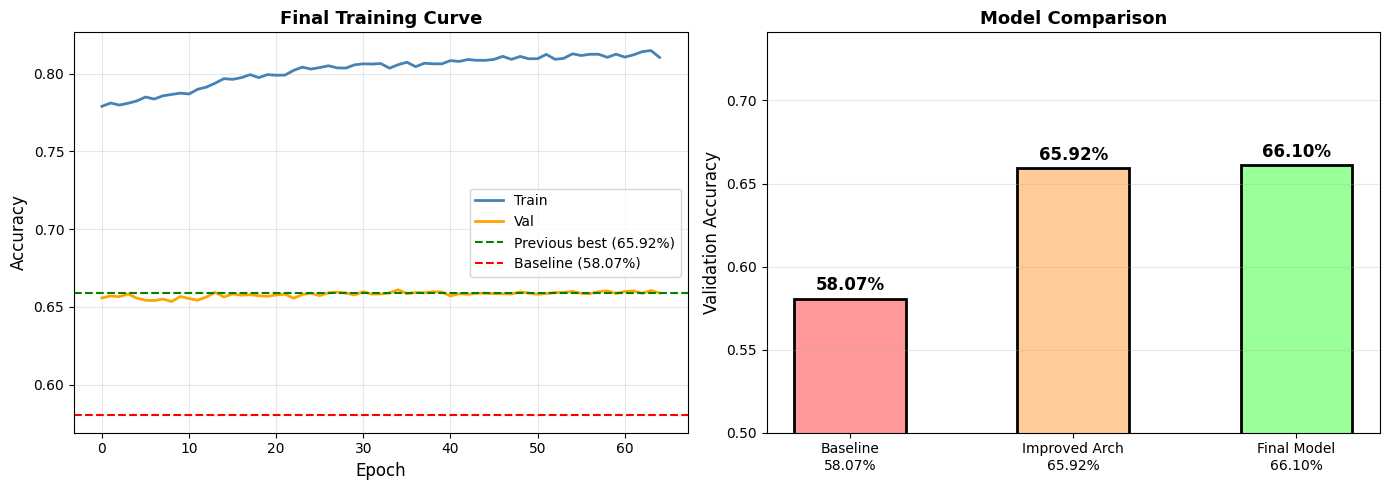

✅ Saved to /kaggle/working/final_results.png


In [21]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---- Training curve ----
axes[0].plot(history_final['train_acc'], label='Train', linewidth=2, color='steelblue')
axes[0].plot(history_final['val_acc'],   label='Val',   linewidth=2, color='orange')
axes[0].axhline(y=0.6592, color='green', linestyle='--', linewidth=1.5, label='Previous best (65.92%)')
axes[0].axhline(y=0.5807, color='red',   linestyle='--', linewidth=1.5, label='Baseline (58.07%)')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Final Training Curve', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# ---- Bar chart ----
labels = ['Baseline\n58.07%', 'Improved Arch\n65.92%', f'Final Model\n{best_acc_final*100:.2f}%']
values = [0.5807, 0.6592, best_acc_final]
colors = ['#ff9999', '#ffcc99', '#99ff99']

bars = axes[1].bar(labels, values, color=colors, edgecolor='black', linewidth=2, width=0.5)
axes[1].set_ylim(0.50, min(max(values) + 0.08, 1.0))
axes[1].set_ylabel('Validation Accuracy', fontsize=12)
axes[1].set_title('Model Comparison', fontsize=13, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

for bar, val in zip(bars, values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val*100:.2f}%', ha='center',
                 fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('/kaggle/working/final_results.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved to /kaggle/working/final_results.png")